retries applied on no/partialt supported ans, if full supported then end

## Loading API Key

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Loading Necessary Libraries

In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

C:\Users\koyel\AppData\Local\Temp\ipykernel_6008\2711615123.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
c:\Users\koyel\Downloads\python_practice\ai_ml_learning_journey\genai_and_agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Basic Steps
- Document Loading
- Chunking 
- Embedding
- Storing to VectorDB 
- Creation of Retriever Object for Further Use
- LLM Object Creation

In [3]:
docs = DirectoryLoader(
    path = 'documents', 
    glob = '*.pdf',
    loader_cls = PyPDFLoader
).load()

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150).split_documents(docs)
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

- For chunking, values for parameters `chunk_size` and `chunk_overlap` is experimentally got here.

In [5]:
retriever = vector_store.as_retriever(search_kwargs = {'k': 4})

- Here as we set `k` to `4`, post retrieval 4 relevant documents will be shared where retrieval is required.

In [6]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

## Define State
- `state` is a class which carries variables and their values at different steps of the workflow.
- Variables in `state` are modified as workflow proceeds.
- Variables:
    - `question`: user query
    - `need_retrieval`: boolean parameter indicating retrieval of documents is needed or not for particular query going to vector database
    - `docs`: list of all retrieved docs
    - `relevant_docs`: list of relevant documents
    - `answer`: final answer which will be showed to user
    - `issup`: boolean parameter indicating RAG generated answer is grounded in relevant documents or not
    - `evidence`: list of strings from relevant documents which supports the answer in case of fully/partially supported
    - `retries`: number of times to regenerate answer from retrieved documents if answer is not supported by evidence
- Can add description in schema itself.
- Here `retries` is newly added in `state` of the workflow.

In [7]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    
    docs: List[Document]
    relevant_docs: list[Document]

    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

## Decision on Requirement of Retrival of Documents
- This below part is to output schema of structured LLM , prompt and node regarding query needs RAG or LLM can answer from its parametric knowledge.

#### Output Schema for Node `decide_retrieval`
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [8]:
class RetrieveDecicision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False"
    )

#### Prompt for Node `decide_retrieval`

In [9]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve = True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve = False for general explanations, definitions, or reasoning taht doesn't need sources.\n"
            "- If unsure. choose True."
        ),
        ("human", "Question: {question}")
    ]
)

#### Structured LLM for Node `decide_retrieval`
- **`IMPORTANT`**: NO `.content` for structured output.

In [10]:
should_retrieve_llm = llm.with_structured_output(RetrieveDecicision)

#### Define Node `decide_retrieval`

In [11]:
def decide_retrieval(state: "State"):
    decision: RetrieveDecicision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question = state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

## Direct Answer Generation
- Below part will generate answer for queries which can be answered by LLM directly without retrieving  document.

#### Prompt for Node `generate_direct`

In [12]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specifics sources, say:\n"
            "I don't know based on my general knowledge."
        ),
        ("human", "{question}")
    ]
)

#### Define Node `generate_direct`

In [13]:
def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question = state["question"]
        )
    )
    return {
        "answer": out.content
    }

## Retrieval of Documents
- Node `retrieve` will retrieve document where required.
#### Define Node `retrieve`
- This nodes does not require any output schema or prompt.
- It just needs `retriever` object defined in `Initial Basic Steps`.
- This node will be used in case `decide_retrieval` decides that query requires to retrieve document. 

In [14]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

## Evaluation of Relevance of Retrieved Documents
#### Output Schema for Node `is_relevant`
- It is working with LLM with output schema `RelevanceDecision` which is having a boolean variable which tells relevant or not.

In [15]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "true if the documment helps answer the question, else False."
    )

#### Prompt for Node `is_relevant`

In [16]:
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a judging document relavance.\n"
            "Return the JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        )
    ]
)

#### Structured LLM for Node `is_relevant`

In [17]:
relevance_llm = llm.with_structured_output(RelevanceDecision)

#### Define Node `is_relevant`
- This node present will decide relevance of retrieved documents.

In [18]:
def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = state["question"],
                document = doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

## Generating Answer by RAG
#### Prompt for Node `generate_from_context`

In [19]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        )
    ]
)

#### Define Node `generate_from_context`
- The `generate_from_context` node present in below section will generate answer based on relevant documents + prompt.

In [20]:
def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state["question"],
            context = context
        )
    )
    return {"answer": out.content, "context": context}

#### Define Node `no_relevant_docs`

In [21]:
def no_relevant_docs(satte: State):
    return {"answer": "No answer found.", "context":""}

## Checking Hallucination of RAG Generated Answer

#### Output Schema for Node `is_sup`

In [22]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

#### Prompt for Node `is_sup`

In [23]:
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

#### Structured Output LLM for Node `is_sup`

In [24]:
issup_llm = llm.with_structured_output(IsSUPDecision)

#### Define Node `is_sup`

In [25]:
def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

## Accepting the RAG Generated Answer
- This node `accept_answer` will work if answer will be fully supported by retrieved documents.
#### Define Node `accept_answer`
- From this node workflow will proceed towards `End`.
- It will keep answer as-is.

In [26]:
def accept_answer(state: State):
    return {} 

## Regeneration of RAG Generated Answer
- Here we can retry to generate answer again via LLM using retrieved documents if previous answer is not grounded in retrieved documents.
- Here this previous answer may be answer to original user's query or it may be answer to the query rewritten in its previous retry.
- This regeneration will happen on output of node `is_sup`.
- It will work in case of retrieval is required.

#### Prompt for Node `revise_answer`

In [27]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

#### Define Node `revise_answer`

In [28]:
def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

## Routing Node Function 
- `route_after_decide` will decide to retrieve documents or directly send query to answer generating LLM.
- This will work based on output of `decide_retrieval`.

In [29]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

- `route_after_relevance` will decide next node based on presence of relevant documents.

In [30]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_relevant_docs"

- In `route_after_issup` to NOT get involved in infinite loop, we will keep a maximum number of permissbale retry.

In [31]:
MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

## Define Graph

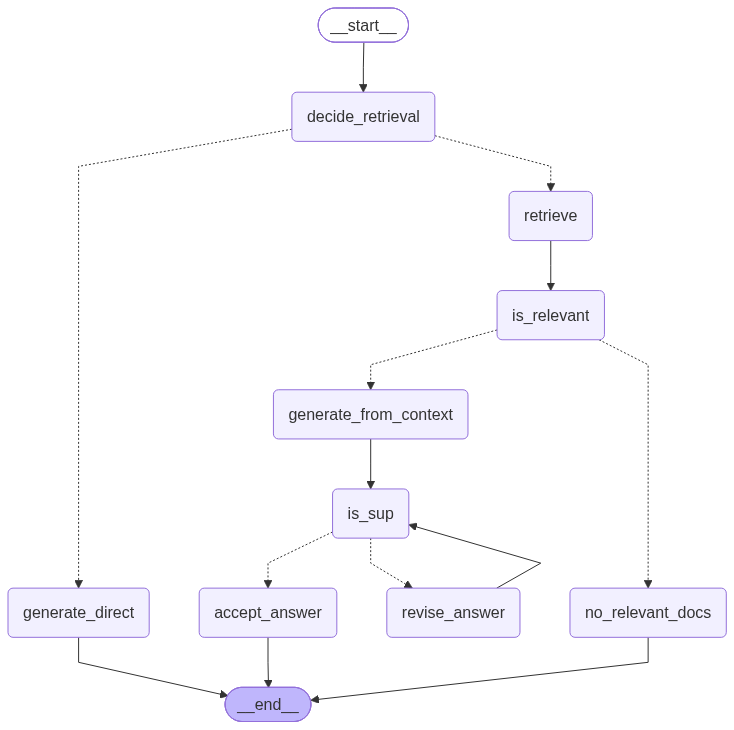

In [32]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)

g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)


g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "no_relevant_docs": "no_relevant_docs"},
)

# If no answer found, end
g.add_edge("no_relevant_docs", END)

# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported -> accept_answer else revise_answer
    {"accept_answer": "accept_answer", "revise_answer": "revise_answer"},
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify
g.add_edge("accept_answer", END)

app = g.compile()
app

## Test on Questions
- Now we will see implementation of retry with questions.

In [33]:
result = app.invoke(
    {
        "question":"How many countries employees of Noventra Systems belong to?",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [34]:
# how many employees does naxa ai have?
# describe nexaai's company culture
# do nexaai plans include a free trial? If yes, how may days?

In [35]:
print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: ['Noventra serves customers in more than 25 countries.']
answer: - "Noventra serves customers in more than 25 countries"


In [36]:
print(result.get("retries"))

1


In [37]:
for doc in result['relevant_docs']:
    print(doc.page_content)

assistants, workflow automation, analytics platforms, and enterprise collaboration software. 
Today, Noventra serves customers in more than 25 countries through regional offices and partner 
networks. 
 
Founders 
Dr. Arjun Mehta 
Founder & Chief Executive Officer (CEO) 
Dr. Mehta previously led enterprise AI research initiatives and has over 18 years of experience in 
artificial intelligence and cloud technologies. 
 
Priya Raman 
Co-Founder & Chief Product Officer (CPO) 
Priya oversees product strategy, customer experience, and long-term product roadmap. 
 
Ethan Brooks


## TODO:
- For question `How many countries employees of Noventra Systems belong to?`, we saw this got 1 relevant document, but generated answer was not supported at first run, then post 1 retry it generated correct answer. Refer same example in [04_check_hallucination.ipynb](04_check_hallucination.ipynb) where it was not not able to generate answer, it was saying no answer found.
- We should understand this behaviour.